/tmp/ipython-input-57488500.py:44: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['CREATION_DATE_TIME'] = pd.to_datetime(data['CREATION_DATE_TIME'], errors='coerce')


Optimal clusters selected: 6, silhouette scores: [np.float64(-0.08566006935755197), np.float64(-0.08394876086184429), np.float64(-0.12277554871239034), np.float64(-0.051103459882269706), np.float64(0.04955004768241627)]


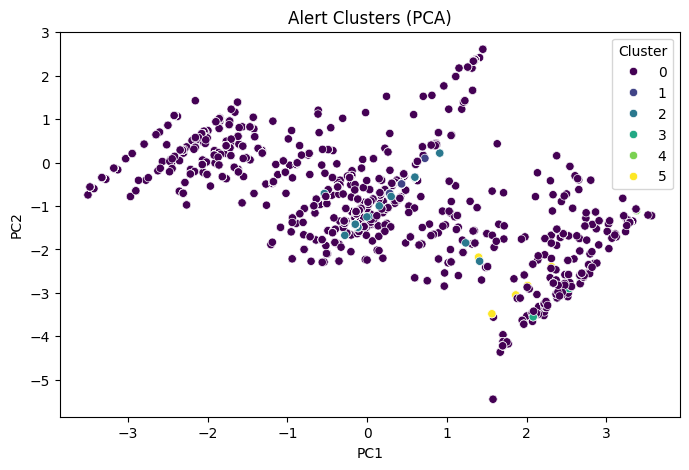

RandomForest: accuracy=1.000, f1=1.000
LogisticRegression: accuracy=0.999, f1=0.999
DecisionTree: accuracy=1.000, f1=1.000

Best model: RandomForest with accuracy=1.000, f1=1.000

Organizational impact: Clusters and severity prediction help focus daily operational attention on alert types and sources that consistently create critical, repetitive, or disruptive errors. This supports proactive intervention and automation prioritization.


In [22]:
# Import dependencies
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, silhouette_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
data = pd.read_csv('Error_Details.csv')

# Data cleaning (missing values + types)
# Standardize column names if needed
data = data.rename(columns={
    'APP_NAME': 'APP_NAME',
    'ERROR_TYPE': 'ERROR_TYPE',
    'CREATION_DATE_TIME': 'CREATION_DATE_TIME',
    'FAULT_SEVERITY': 'FAULT_SEVERITY',
    'ERROR_COUNT': 'ERROR_COUNT'
})

# Replace 'NaN' string with actual np.nan
data = data.replace('NaN', np.nan)

# Impute numeric columns ('ERROR_COUNT') using median for missing and cap outliers at 99th percentile
data['ERROR_COUNT'] = pd.to_numeric(data['ERROR_COUNT'], errors='coerce')
error_count_cap = data['ERROR_COUNT'].quantile(0.99)
data['ERROR_COUNT'] = np.where(data['ERROR_COUNT'] > error_count_cap, error_count_cap, data['ERROR_COUNT'])
data['ERROR_COUNT'] = SimpleImputer(strategy='median').fit_transform(data[['ERROR_COUNT']])

# Impute categorical columns
data['APP_NAME'] = data['APP_NAME'].fillna('Unknown').astype(str)
data['ERROR_TYPE'] = data['ERROR_TYPE'].fillna('Unknown').astype(str)
data['FAULT_SEVERITY'] = data['FAULT_SEVERITY'].fillna(data['FAULT_SEVERITY'].mode()[0]).astype(str)

# Parse date column and drop errors
data['CREATION_DATE_TIME'] = pd.to_datetime(data['CREATION_DATE_TIME'], errors='coerce')
data = data.dropna(subset=['CREATION_DATE_TIME'])

# Feature engineering - convert date to timestamp
data['CREATION_TIMESTAMP'] = data['CREATION_DATE_TIME'].astype('int64') // 10**9

# Encode categorical variables (OneHot for app/error, ordinal for severity)
encoder = OneHotEncoder() # Removed sparse=False
cat_features = data[['APP_NAME', 'ERROR_TYPE']]
cat_encoded = encoder.fit_transform(cat_features)
cat_encoded_names = encoder.get_feature_names_out(['APP_NAME', 'ERROR_TYPE'])
cat_df = pd.DataFrame(cat_encoded.toarray(), columns=cat_encoded_names) # Convert to dense array

# Encode severity as integer code
data['FAULT_SEVERITY_CODE'] = pd.factorize(data['FAULT_SEVERITY'])[0]

# Combine all features into final modeling set
numerical_data = pd.concat([cat_df, data[['ERROR_COUNT', 'FAULT_SEVERITY_CODE', 'CREATION_TIMESTAMP']].reset_index(drop=True)], axis=1)

# Standardize feature space
scaler = StandardScaler()
numerical_data_scaled = scaler.fit_transform(numerical_data)

# KMeans clustering (goal: group alerts for prioritization)
sil_scores = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10) # Added n_init to avoid warning
    sil_scores.append(silhouette_score(numerical_data_scaled, km.fit_predict(numerical_data_scaled)))

optimal_k = np.argmax(sil_scores) + 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10) # Added n_init to avoid warning
data['Cluster'] = kmeans.fit_predict(numerical_data_scaled)

print(f'Optimal clusters selected: {optimal_k}, silhouette scores: {sil_scores}')

# Plot clusters (2D PCA for visualization)
pca = PCA(n_components=2)
reduced = pca.fit_transform(numerical_data_scaled)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=data['Cluster'], palette='viridis')
plt.title('Alert Clusters (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# Predictive classification: Classify Fault Severity Code as an example of prioritization
X = numerical_data_scaled
y = data['FAULT_SEVERITY_CODE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42)
}

metrics = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']
    metrics.append({'model': name, 'accuracy': acc, 'f1': f1})
    print(f"{name}: accuracy={acc:.3f}, f1={f1:.3f}")

# Model selection
best = max(metrics, key=lambda x: x['accuracy'])
print(f"\nBest model: {best['model']} with accuracy={best['accuracy']:.3f}, f1={best['f1']:.3f}")

# Goal Reflection
print('\nOrganizational impact: Clusters and severity prediction help focus daily operational attention on alert types and sources that consistently create critical, repetitive, or disruptive errors. This supports proactive intervention and automation prioritization.')

In [21]:
# Save classification reports to Excel
excel_file_path = 'classification_reports.xlsx'

# Access results from the global scope if not defined locally
if 'results' not in locals() and 'results' in globals():
    results = globals()['results']

with pd.ExcelWriter(excel_file_path) as writer:
    for name, res in results.items():
        report_df = pd.DataFrame(res['report']).transpose()
        report_df.to_excel(writer, sheet_name=name)

print(f"Classification reports saved to {excel_file_path}")

Classification reports saved to classification_reports.xlsx


In [23]:
def error_distribution_by_application(data):
    """Analyzes the distribution of errors by application."""
    return data['APP_NAME'].value_counts().reset_index().rename(columns={'index': 'APP_NAME', 'APP_NAME': 'Error Count'})

def fault_severity_analysis(data):
    """Analyzes the distribution of errors by fault severity."""
    return data['FAULT_SEVERITY'].value_counts().reset_index().rename(columns={'index': 'FAULT_SEVERITY', 'FAULT_SEVERITY': 'Error Count'})

def error_type_distribution(data):
    """Analyzes the distribution of errors by error type."""
    return data['ERROR_TYPE'].value_counts().reset_index().rename(columns={'index': 'ERROR_TYPE', 'ERROR_TYPE': 'Error Count'})

def error_trends_over_time(data):
    """Analyzes error trends over time."""
    return data.groupby(data['CREATION_DATE_TIME'].dt.to_period('M')).size().reset_index(name='Error Count').rename(columns={'CREATION_DATE_TIME': 'Month'})

def error_heatmap(data):
    """Generates data for an error heatmap (e.g., by app and error type)."""
    return pd.crosstab(data['APP_NAME'], data['ERROR_TYPE'])

def top_10_applications(data):
    """Identifies the top 10 applications with the most errors."""
    return data['APP_NAME'].value_counts().nlargest(10).reset_index().rename(columns={'index': 'APP_NAME', 'APP_NAME': 'Error Count'})

def top_10_alerts(data):
    """Identifies the top 10 alerts (combination of app and error type)."""
    return data.groupby(['APP_NAME', 'ERROR_TYPE']).size().nlargest(10).reset_index(name='Error Count')

def clustering_result(data):
    """Provides the clustering result with relevant features."""
    return data[['APP_NAME', 'ERROR_TYPE', 'FAULT_SEVERITY', 'ERROR_COUNT', 'CREATION_DATE_TIME', 'Cluster']]

def error_severity_by_application(data):
    """Analyzes error severity by application."""
    return pd.crosstab(data['APP_NAME'], data['FAULT_SEVERITY'])

def time_based_analysis(data):
    """Provides a time-based analysis of errors."""
    return data.groupby(data['CREATION_DATE_TIME'].dt.date).size().reset_index(name='Error Count').rename(columns={'CREATION_DATE_TIME': 'Date'})

def plot_clusters(data, numerical_data, kmeans):
    """Generates data for cluster visualization using PCA."""
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(numerical_data)
    pca_df = pd.DataFrame(reduced, columns=['PC1', 'PC2'])
    pca_df['Cluster'] = data['Cluster'].values # Ensure index alignment
    return pca_df

def cluster_centers_analysis(kmeans, encoder):
    """Analyzes the cluster centers."""
    # This function needs access to the original feature names after encoding
    # Assuming 'encoder' is the OneHotEncoder used for APP_NAME and ERROR_TYPE
    # and the numerical features are in the same order as concatenated
    feature_names = list(encoder.get_feature_names_out(['APP_NAME', 'ERROR_TYPE'])) + ['ERROR_COUNT', 'FAULT_SEVERITY_CODE', 'CREATION_TIMESTAMP']
    cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=feature_names)
    return cluster_centers

def error_distribution_within_clusters(data):
    """Analyzes the distribution of errors within each cluster."""
    return data.groupby('Cluster').size().reset_index(name='Error Count')

In [25]:
# Generate reports and save to Excel

with pd.ExcelWriter('analysis_results.xlsx') as writer:
    error_distribution_by_application(data).to_excel(writer, sheet_name='Error Distribution by App')
    fault_severity_analysis(data).to_excel(writer, sheet_name='Fault Severity Analysis')
    error_type_distribution(data).to_excel(writer, sheet_name='Error Type Distribution')
    error_trends_over_time(data).to_excel(writer, sheet_name='Error Trends Over Time')
    error_heatmap(data).to_excel(writer, sheet_name='Error Heatmap')
    top_10_applications(data).to_excel(writer, sheet_name='Top 10 Applications')
    top_10_alerts(data).to_excel(writer, sheet_name='Top 10 Alerts', index=False)
    clustering_result(data).to_excel(writer, sheet_name='Clustering Result', index=False)
    error_severity_by_application(data).to_excel(writer, sheet_name='Error Severity by App')
    time_based_analysis(data).to_excel(writer, sheet_name='Time-based Analysis')

    # Cluster visualization and analysis
    pca_df = plot_clusters(data, numerical_data, kmeans)
    pca_df.to_excel(writer, sheet_name='Cluster Visualization', index=False)
    cluster_centers_df = cluster_centers_analysis(kmeans, encoder)
    cluster_centers_df.to_excel(writer, sheet_name='Cluster Centers Analysis', index=False)
    cluster_error_counts = error_distribution_within_clusters(data)
    cluster_error_counts.to_excel(writer, sheet_name='Error Distribution in Clusters')

print("Analysis results saved to analysis_results.xlsx")

Analysis results saved to analysis_results.xlsx
